In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import spacy
from collections import Counter

# load spaCy model
nlp = spacy.load('en_core_web_sm')

# set random seed for reproducibility
np.random.seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/NLP Project/mtsamples.csv')
print(df.shape)
df.head()

Mounted at /content/drive
(4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
# check data info
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

Missing Values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


Medical Specialties Distribution:
medical_specialty
Surgery                       1103
Cardiovascular / Pulmonary     372
Orthopedic                     355
Radiology                      273
General Medicine               259
Gastroenterology               230
Neurology                      223
Obstetrics / Gynecology        160
Urology                        158
ENT - Otolaryngology            98
Name: count, dtype: int64


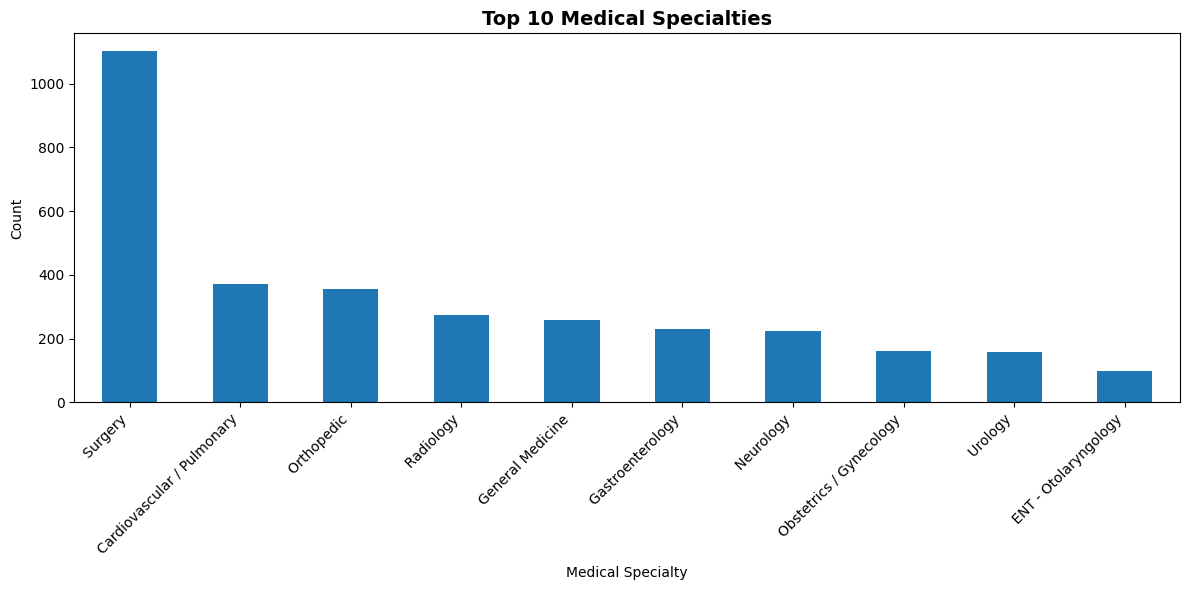

In [ ]:
# Analyze medical specialties distribution
print("Medical Specialties Distribution:")
specialty_counts = df['medical_specialty'].value_counts()
#print(specialty_counts.head(10))

ADMIN_CATEGORIES = {
    ' Consult - History and Phy.',
    ' SOAP / Chart / Progress Notes',
    ' Discharge Summary',
    ' Letters',
    ' Emergency Room Reports',
}
# Filter out admin categories FIRST, then take top 4
clinical_counts = specialty_counts[~specialty_counts.index.isin(ADMIN_CATEGORIES)]
print(clinical_counts.head(10))

# Visualize
plt.figure(figsize=(12, 6))
clinical_counts.head(10).plot(kind='bar')
plt.title('Top 10 Medical Specialties', fontsize=14, fontweight='bold')
plt.xlabel('Medical Specialty')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Select top 4 specialties with enough data
top_specialties = clinical_counts.head(4).index.tolist()
print(f"Selected Specialties: {top_specialties}")

# Filter dataset
df_filtered = df[df['medical_specialty'].isin(top_specialties)].copy()
df_filtered = df_filtered.dropna(subset=['transcription', 'medical_specialty'])

print(f"\nFiltered dataset shape: {df_filtered.shape}")
print(f"\nSpecialty distribution after filtering:")
print(df_filtered['medical_specialty'].value_counts())

Selected Specialties: [' Surgery', ' Cardiovascular / Pulmonary', ' Orthopedic', ' Radiology']

Filtered dataset shape: (2087, 6)

Specialty distribution after filtering:
medical_specialty
Surgery                       1088
Cardiovascular / Pulmonary     371
Orthopedic                     355
Radiology                      273
Name: count, dtype: int64


---
# **Phase 1: Clinical Preprocessing**

## Noise Removal using Regex

In [ ]:
def remove_headers(text):
    if not isinstance(text, str):
        return ""
    # Define regex patterns for common headers
    patterns = [
        r'Sample Name:.*?\n',
        r'ID:.*?\n',
        r'Date:.*?\n',
        r'Description:.*?\n',
        r'\(Medical Transcription Sample Report\)',
        r'SAMPLE NAME:.*?\n',
        r'DESCRIPTION:.*?\n',
    ]
    cleaned = text
    for pattern in patterns:
        cleaned = re.sub(pattern, '', cleaned, flags=re.IGNORECASE)
    cleaned = cleaned.lower()
    cleaned = re.sub(r'\b\d+\.(?=\s)', '', cleaned)    # remove numbered lists like "1. 2. 3."
    cleaned = re.sub(r',+', ',', cleaned)   # remove multiple commas
    cleaned = re.sub(r'[a-z0-9\- ]+:\s*', '', cleaned)    # remove section titles like "doppler:" or "2-d m-mode:"
    cleaned = re.sub(r'\s+', ' ', cleaned)    # remove extra spaces
    cleaned = re.sub(r'[^a-zA-Z0-9%.\s]', '', cleaned)   # keep decimals and percentages
    return cleaned.strip()


# test the function
sample_text = df_filtered['transcription'].iloc[0]
print("BEFORE CLEANING:")
print(sample_text[:500])
print("\n" + "="*80 + "\n")
print("AFTER CLEANING:")
print(remove_headers(sample_text)[:500])

BEFORE CLEANING:
2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericardial effusion.,6.  Normal morphology of aortic valve, mitral valve, tricuspid valve, and pulmonary valve.,7.  PA systolic pressure is 36 mmHg.,DOPPLER: , ,1.  Mild mitral and tricuspid regurgitation.,2.  Trace aortic and pulmonary regurgitation.


AFTER CLEANING:
left atrial enlargement with left atrial diameter of 4.7 cm. normal size right and left ventricle. normal lv systolic function with left ventricular ejection fraction of 51%. normal lv diastolic function. no pericardial effusion. normal morphology of aortic valve mitral valve tricuspid valve and pulmonary valve. pa systolic pressure is 36 mmhg.  mild mitral and tricuspid regurgitation. trace aortic and pulmonary regurgitation.


## Abbreviation Expansion

In [ ]:
# Medical abbreviations dictionary
medical_abbrev = {
    'pt': 'patient',
    'pts': 'patients',
    'hx': 'history',
    'dx': 'diagnosis',
    'tx': 'treatment',
    'rx': 'prescription',
    'sx': 'symptoms',
    'fx': 'fracture',
    'c/o': 'complains of',
    'y/o': 'year old',
    'yo': 'year old',
    'w/': 'with',
    'w/o': 'without',
    'h/o': 'history of',
    's/p': 'status post',
    'r/o': 'rule out',
    'sob': 'shortness of breath',
    'cp': 'chest pain',
    'bp': 'blood pressure',
    'hr': 'heart rate',
    'wbc': 'white blood cell',
    'rbc': 'red blood cell',
}

def expand_abbreviations(text, abbrev_dict):
    if not isinstance(text, str):
        return ""
    expanded = text
    for abbrev, full_form in abbrev_dict.items():
        # use word boundaries to match complete words only
        pattern = r'\b' + re.escape(abbrev) + r'\b'
        expanded = re.sub(pattern, full_form, expanded, flags=re.IGNORECASE)
    return expanded

# test abbreviation expansion
test_text = "Pt is a 45 y/o male c/o chest pain and sob. Hx of hypertension. R/o MI."
print("BEFORE EXPANSION:")
print(test_text)
print("\nAFTER EXPANSION:")
print(expand_abbreviations(test_text, medical_abbrev))

BEFORE EXPANSION:
Pt is a 45 y/o male c/o chest pain and sob. Hx of hypertension. R/o MI.

AFTER EXPANSION:
patient is a 45 year old male complains of chest pain and shortness of breath. history of hypertension. rule out MI.


## Tokenization and Lemmatization

In [ ]:
def tokenize_and_lemmatize(text):
    if not isinstance(text, str):
        return [], ""

    doc = nlp(text.lower())
    # Extract lemmatized tokens (excluding stop words and punctuation)
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_punct and token.is_alpha]
    # Create processed text
    processed_text = ' '.join(tokens)

    return tokens, processed_text

# test tokenization
test_text = "The patient complained of severe chest pains and breathing difficulties."
tokens, processed = tokenize_and_lemmatize(test_text)
print("Original:", test_text)
print("\nTokens:", tokens)
print("\nProcessed:", processed)

Original: The patient complained of severe chest pains and breathing difficulties.

Tokens: ['patient', 'complain', 'severe', 'chest', 'pain', 'breathe', 'difficulty']

Processed: patient complain severe chest pain breathe difficulty


## Complete Preprocessing Pipeline

In [ ]:
def preprocess_pipeline(text):
    text = remove_headers(text)
    text = expand_abbreviations(text, medical_abbrev)
    tokens, processed_text = tokenize_and_lemmatize(text)
    return processed_text

# Apply preprocessing to entire dataset
print("Preprocessing all transcriptions")
df_filtered['cleaned_text'] = df_filtered['transcription'].apply(preprocess_pipeline)

print("Preprocessing complete")
print(f"\nSample cleaned text:")
print(df_filtered['cleaned_text'].iloc[0][:500])

Preprocessing all transcriptions
Preprocessing complete

Sample cleaned text:
leave atrial enlargement leave atrial diameter cm normal size right left ventricle normal lv systolic function leave ventricular ejection fraction normal lv diastolic function pericardial effusion normal morphology aortic valve mitral valve tricuspid valve pulmonary valve pa systolic pressure mmhg mild mitral tricuspid regurgitation trace aortic pulmonary regurgitation


---
# **Phase 2: Entity Extraction via POS Tagging**

## POS Tagging and Entity Extraction

In [ ]:
MEDICAL_STOPWORDS = {
    'patient', 'procedure', 'history', 'noted', 'report', 'performed',
    'using', 'place', 'taken', 'given', 'left', 'right', 'well',
    'area', 'time', 'day', 'year', 'old', 'male', 'female',
    'normal', 'mild', 'moderate', 'severe', 'small', 'large',
    'cm', 'mm', 'mg', 'ml', 'cc',
    'skin', 'tissue', 'wall', 'layer', 'site',
    'reveal', 'show', 'demonstrate', 'appear', 'suggest', 'indicate',
    'identify', 'find', 'note', 'use', 'make', 'include', 'follow',
}

def extract_medical_entities(text):
    if not isinstance(text, str):
        return {'nouns': [], 'adjectives': []}

    doc = nlp(text)
    nouns = []
    adjectives = []

    for token in doc:
        lemma = token.lemma_.lower()
        if token.pos_ in ['NOUN', 'PROPN']:
            if lemma not in MEDICAL_STOPWORDS and len(lemma) > 2:
                nouns.append(lemma)
        elif token.pos_ == 'ADJ':
            adjectives.append(lemma)

    return {
        'nouns': nouns,
        'adjectives': adjectives
    }

# test entity extraction
sample = "The patient has severe chest pain and acute respiratory distress."
entities = extract_medical_entities(sample)
print("Sample text:", sample)
print("\nExtracted Entities:")
print(f"Nouns (Symptoms/Body Parts): {entities['nouns']}")
print(f"Adjectives (Descriptors): {entities['adjectives']}")

Sample text: The patient has severe chest pain and acute respiratory distress.

Extracted Entities:
Nouns (Symptoms/Body Parts): ['chest', 'pain', 'distress']
Adjectives (Descriptors): ['severe', 'acute', 'respiratory']


In [ ]:
# extract entities for all transcriptions
print("Extracting entities from all transcriptions")
df_filtered['entities'] = df_filtered['cleaned_text'].apply(extract_medical_entities)

# separate nouns and adjectives
df_filtered['nouns'] = df_filtered['entities'].apply(lambda x: x['nouns'])
df_filtered['adjectives'] = df_filtered['entities'].apply(lambda x: x['adjectives'])

print("Entity extraction complete!")

Extracting entities from all transcriptions
Entity extraction complete!


## Vocabulary Analysis by Specialty

In [ ]:
def get_top_nouns_by_specialty(df, specialty, top_n=10):
    specialty_df = df[df['medical_specialty'] == specialty]

    all_nouns = []
    for nouns_list in specialty_df['nouns']:
        all_nouns.extend(nouns_list)

    noun_counts = Counter(all_nouns)
    return noun_counts.most_common(top_n)

print("Top 5 Nouns by Medical Specialty:")

vocabulary_comparison = {}

for specialty in top_specialties:
    top_nouns = get_top_nouns_by_specialty(df_filtered, specialty, top_n=5)
    vocabulary_comparison[specialty] = top_nouns

    print(f"\n{specialty}:")
    for noun, count in top_nouns:
        print(f"  {noun}: {count}")

# comparison table
vocab_df = pd.DataFrame(vocabulary_comparison).T
vocab_df.columns = [f'Top {i+1}' for i in range(5)]
print("\nVocabulary Comparison Table:")
print(vocab_df)

Top 5 Nouns by Medical Specialty:

 Surgery:
  incision: 1773
  suture: 1526
  position: 1220
  room: 1203
  artery: 1117

 Cardiovascular / Pulmonary:
  artery: 1092
  chest: 502
  catheter: 466
  pressure: 420
  heart: 388

 Orthopedic:
  pain: 726
  incision: 489
  knee: 456
  position: 430
  bone: 384

 Radiology:
  image: 195
  evidence: 179
  artery: 174
  change: 131
  pain: 123

Vocabulary Comparison Table:
                                       Top 1            Top 2  \
Surgery                     (incision, 1773)   (suture, 1526)   
Cardiovascular / Pulmonary    (artery, 1092)     (chest, 502)   
Orthopedic                       (pain, 726)  (incision, 489)   
Radiology                       (image, 195)  (evidence, 179)   

                                       Top 3            Top 4           Top 5  
Surgery                     (position, 1220)     (room, 1203)  (artery, 1117)  
Cardiovascular / Pulmonary   (catheter, 466)  (pressure, 420)    (heart, 388)  
Orthopedic     

## Word Cloud Visualization

In [ ]:
# get and print the top 4 specialities
print("\nTOP 4 SPECIALTIES SELECTED:")

top_4 = clinical_counts.head(4)
for rank, (specialty, count) in enumerate(top_4.items(), 1):
    print(f"{rank}. {specialty}: {count} samples")


TOP 4 SPECIALTIES SELECTED:
1.  Surgery: 1103 samples
2.  Cardiovascular / Pulmonary: 372 samples
3.  Orthopedic: 355 samples
4.  Radiology: 273 samples


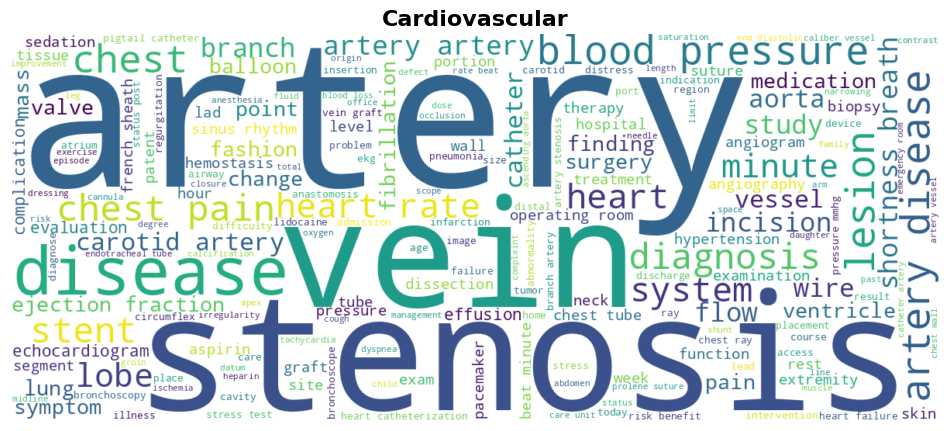

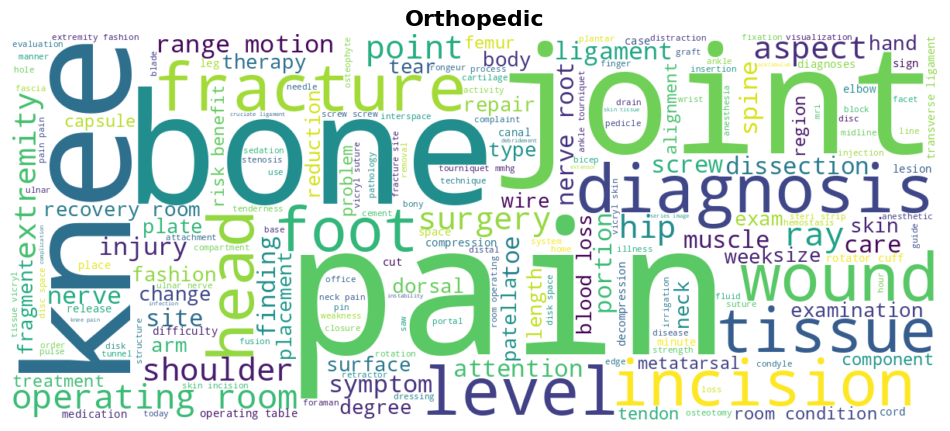

In [ ]:
CLOUD_STOPWORDS = {
    "patient", "time", "history", "procedure", "evidence", "area",
    "position", "day", "month", "year", "note", "view", "side",
    "left", "right", "well", "normal", "mild", "moderate", "severe",
    "cm", "mm", "mg", "male", "female", "old"
}

def get_clean_nouns(df, specialty):
    docs = df[df['medical_specialty'] == specialty]['transcription']
    nouns = []
    for text in docs:
        if not isinstance(text, str):
            continue
        doc = nlp(text.lower())
        nouns.extend([
            t.lemma_ for t in doc
            if t.pos_ == "NOUN"
            and len(t.lemma_) > 2
            and not t.is_stop
            and t.lemma_ not in CLOUD_STOPWORDS
        ])
    return " ".join(nouns)

def find_specialty_key(df, keyword):
    for sp in df['medical_specialty'].unique():
        if keyword.lower() in sp.lower():
            return sp
    return None

cardio_key = find_specialty_key(df_filtered, "cardio")
ortho_key  = find_specialty_key(df_filtered, "orth")

# Generate clouds
for key, title in [(cardio_key, "Cardiovascular"), (ortho_key, "Orthopedic")]:
    text = get_clean_nouns(df_filtered, key)
    wc = WordCloud(width=1200, height=500, background_color="white").generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"{title}", fontsize=16, fontweight='bold')
    plt.show()

---

# **Phase 3: Syntax & Negation Analysis**

## Dependency Parsing Visualization

In [ ]:
from spacy import displacy

def visualize_dependencies(text):
    doc = nlp(text)

    displacy.render(doc, style='dep', jupyter=True, options={'distance': 120})

# example sentences
examples = [
    "Patient denies chest pain.",
    "No fever or chills reported.",
    "Patient has severe headache.",
    "No history of diabetes.",
    "Patient reports shortness of breath."
]

print("Dependency Parse Visualization Examples:")

for example in examples:
    print(f"Sentence: {example}")
    visualize_dependencies(example)
    print("\n")

Dependency Parse Visualization Examples:
Sentence: Patient denies chest pain.




Sentence: No fever or chills reported.




Sentence: Patient has severe headache.




Sentence: No history of diabetes.




Sentence: Patient reports shortness of breath.


## Negation Detection Function

In [ ]:
def detect_negation(text, target_entities=None):

    if not isinstance(text, str):
        return []

    doc = nlp(text)

    negation_words = {
        'no', 'not', 'never', 'none', 'nobody', 'nothing', 'neither', 'nowhere',
        'denies', 'denied', 'deny', 'without', 'lack', 'lacks', 'lacking',
        'absent', 'negative', 'free', 'unremarkable'
    }

    results = []

    for token in doc:
        # check if token is a noun
        if token.pos_ in ['NOUN', 'PROPN']:
            if target_entities and token.text.lower() not in [e.lower() for e in target_entities]:
                continue

            is_negated = False
            negation_source = None

            # check ancestors (parents in dependency tree)
            for ancestor in token.ancestors:
                if ancestor.text.lower() in negation_words:
                    is_negated = True
                    negation_source = ancestor.text
                    break

            # check children (dependents)
            if not is_negated:
                for child in token.children:
                    if child.text.lower() in negation_words or child.dep_ == 'neg':
                        is_negated = True
                        negation_source = child.text
                        break

            # check siblings (tokens with same head)
            if not is_negated:
                for sibling in token.head.children:
                    if sibling.text.lower() in negation_words and sibling != token:
                        is_negated = True
                        negation_source = sibling.text
                        break

            results.append({
                'Entity': token.text,
                'Status': 'Negated' if is_negated else 'Present',
                'Negation_Word': negation_source if is_negated else None,
                'Context': text
            })

    return results

In [ ]:
# test negation detection with various examples
test_sentences = [
    "Patient denies chest pain.",
    "No fever or chills.",
    "Patient has severe headache.",
    "Heart sounds normal without murmur.",
    "Denies any recent trauma."
]

for sentence in test_sentences:
    print("\nSentence:", sentence)

    negation_results = detect_negation(sentence)

    if negation_results:
        for result in negation_results:
            negated = result['Status'] == 'Negated'
            line = f"Entity: {result['Entity']:<15} | Negated: {negated}"

            if result['Negation_Word']:
                line += f" | Trigger: {result['Negation_Word']}"

            print(line)
    else:
        print("No entities detected.")

    print()


Sentence: Patient denies chest pain.
Entity: Patient         | Negated: True | Trigger: denies
Entity: chest           | Negated: True | Trigger: denies
Entity: pain            | Negated: True | Trigger: denies


Sentence: No fever or chills.
Entity: fever           | Negated: True | Trigger: No
Entity: chills          | Negated: True | Trigger: No


Sentence: Patient has severe headache.
Entity: Patient         | Negated: False
Entity: headache        | Negated: False


Sentence: Heart sounds normal without murmur.
Entity: Heart           | Negated: True | Trigger: without


Sentence: Denies any recent trauma.
Entity: trauma          | Negated: True | Trigger: Denies



---

# **Phase 4: Specialty Classification**

## Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from sklearn.utils import resample

min_count = df_filtered['medical_specialty'].value_counts().min()

balanced_dfs = []
for spec in top_specialties:
    spec_df = df_filtered[df_filtered['medical_specialty'] == spec]
    if len(spec_df) > min_count:
        spec_df = resample(spec_df, n_samples=min_count, random_state=42)
    balanced_dfs.append(spec_df)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42)
print("After balancing:")
print(df_balanced['medical_specialty'].value_counts())

After balancing:
medical_specialty
Cardiovascular / Pulmonary    273
Surgery                       273
Radiology                     273
Orthopedic                    273
Name: count, dtype: int64


## TF-IDF Vectorization

In [ ]:
X = df_balanced['transcription'].fillna('')
y = df_balanced['medical_specialty']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Training matrix: {X_train_tfidf.shape}")
print(f"Test matrix:     {X_test_tfidf.shape}")

Training matrix: (873, 15000)
Test matrix:     (219, 15000)


## Naive Bayes

In [ ]:
nb_classifier = MultinomialNB(alpha=0.1)
nb_classifier.fit(X_train_tfidf, y_train)
y_pred_nb = nb_classifier.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

Naive Bayes Accuracy: 0.7032 (70.32%)


## Logistic Regression

In [ ]:
lr_classifier = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', C=1)
lr_classifier.fit(X_train_tfidf, y_train)
y_pred_lr = lr_classifier.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

Logistic Regression Accuracy: 0.7260 (72.60%)


## Confusion Matrix

Best Model: Logistic Regression
Accuracy:   0.7260



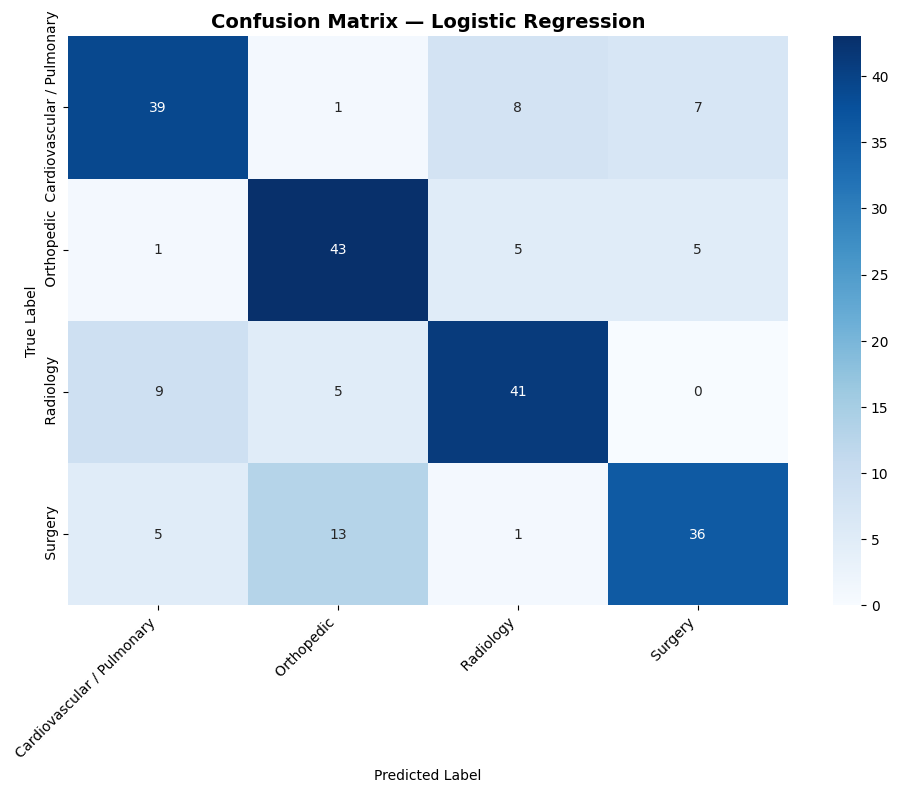

                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.72      0.71      0.72        55
                 Orthopedic       0.69      0.80      0.74        54
                  Radiology       0.75      0.75      0.75        55
                    Surgery       0.75      0.65      0.70        55

                   accuracy                           0.73       219
                  macro avg       0.73      0.73      0.73       219
               weighted avg       0.73      0.73      0.73       219



In [ ]:
best_model  = lr_classifier if lr_accuracy > nb_accuracy else nb_classifier
y_pred_best = y_pred_lr     if lr_accuracy > nb_accuracy else y_pred_nb
model_name  = "Logistic Regression" if lr_accuracy > nb_accuracy else "Naive Bayes"

print(f"Best Model: {model_name}")
print(f"Accuracy:   {max(nb_accuracy, lr_accuracy):.4f}\n")

labels = best_model.classes_
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, labels=labels))

## Confusion Analysis

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

misclassifications = []
for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j and cm[i, j] > 0:
            misclassifications.append({
                'True': true_label,
                'Predicted': pred_label,
                'Count': cm[i, j],
                'Pct': cm_normalized[i, j] * 100
            })

misclassifications.sort(key=lambda x: x['Count'], reverse=True)

print("Most Common Misclassifications:")
for m in misclassifications[:5]:
    print(f"  {m['True']} → {m['Predicted']}: {m['Count']} samples ({m['Pct']:.1f}%)")

Most Common Misclassifications:
   Surgery →  Orthopedic: 13 samples (23.6%)
   Radiology →  Cardiovascular / Pulmonary: 9 samples (16.4%)
   Cardiovascular / Pulmonary →  Radiology: 8 samples (14.5%)
   Cardiovascular / Pulmonary →  Surgery: 7 samples (12.7%)
   Orthopedic →  Radiology: 5 samples (9.3%)
